# Ejercicio 3: Diferenciación Numérica en Python
En este notebook se implementan y comparan dos esquemas de diferencias finitas sobre datos discretos equiespaciados:
1. **Diferencia Hacia Adelante ($O(h)$)**
2. **Diferencia Centrada ($O(h^2)$)**
3. **Comparación con la función nativa `np.gradient()` de NumPy**

In [1]:
import time
import matplotlib.pyplot as plt
import numpy as np

# Carga de datos desde el archivo CSV (ajusta el nombre del archivo si es necesario)
data = np.loadtxt("/home/sag/MCEI_2620/taller_integracion/datos_sensor.csv", delimiter=",", skiprows=1)
x = data[:, 0]
y = data[:, 1]

N = len(x)
h = x[1] - x[0]  # Paso uniforme de la malla

**Diferencias**

In [2]:
# -------------------------------------------------------------------------
# A. DIFERENCIA HACIA ADELANTE (FORWARD DIFFERENCE - O(h))
# -------------------------------------------------------------------------
t0 = time.perf_counter()

df_fwd = np.zeros_like(y)
df_fwd[:-1] = (y[1:] - y[:-1]) / h
df_fwd[-1] = (y[-1] - y[-2]) / h  # Borde final: Backward

t_fwd = (time.perf_counter() - t0) * 1000  # Tiempo en ms

# -------------------------------------------------------------------------
# B. DIFERENCIA CENTRADA (CENTRAL DIFFERENCE - O(h^2))
# -------------------------------------------------------------------------
t0 = time.perf_counter()

df_cent = np.zeros_like(y)
df_cent[1:-1] = (y[2:] - y[:-2]) / (2 * h)
df_cent[0] = (y[1] - y[0]) / h  # Borde inicial: Forward
df_cent[-1] = (y[-1] - y[-2]) / h  # Borde final: Backward

t_cent = (time.perf_counter() - t0) * 1000  # Tiempo en ms

# -------------------------------------------------------------------------
# C. FUNCIÓN NATIVA DE NUMPY (np.gradient)
# -------------------------------------------------------------------------
t0 = time.perf_counter()

df_numpy = np.gradient(y, h)

t_native = (time.perf_counter() - t0) * 1000  # Tiempo en ms

# -------------------------------------------------------------------------
# D. IMPRESIÓN DE RESULTADOS
# -------------------------------------------------------------------------
print("=== RENDIMIENTO Y TIEMPOS DE EJECUCIÓN ===")
print(f"Diferencia Hacia Adelante O(h):   {t_fwd:.4f} ms")
print(f"Diferencia Centrada O(h^2):       {t_cent:.4f} ms")
print(f"Nativa np.gradient():             {t_native:.4f} ms\n")

print(f"Paso de malla (h): {h:.6f}")
print("Muestra de valores en el punto interior x[9] (índice 9 = elemento 10):")
print(f"  - Forward:     {df_fwd[9]:.6f}")
print(f"  - Centrada:    {df_cent[9]:.6f}")
print(f"  - np.gradient: {df_numpy[9]:.6f}")

=== RENDIMIENTO Y TIEMPOS DE EJECUCIÓN ===
Diferencia Hacia Adelante O(h):   0.2953 ms
Diferencia Centrada O(h^2):       0.1485 ms
Nativa np.gradient():             0.1586 ms

Paso de malla (h): 0.200000
Muestra de valores en el punto interior x[9] (índice 9 = elemento 10):
  - Forward:     0.322968
  - Centrada:    0.286924
  - np.gradient: 0.286924


In [ ]:
# Tomando la diferencia centrada como referencia
error_abs = np.abs(df_cent - df_fwd)

mae = np.mean(error_abs)
rmse = np.sqrt(np.mean((df_cent - df_fwd) ** 2))

print(f"MAE (Error Absoluto Medio Forward vs Centrada): {mae:.6f}")
print(f"RMSE (Error Cuadrático Medio):                  {rmse:.6f}")

MAE (Error Absoluto Medio Forward vs Centrada): 0.040580
RMSE (Error Cuadrático Medio):                 0.046652


**Gráficas**

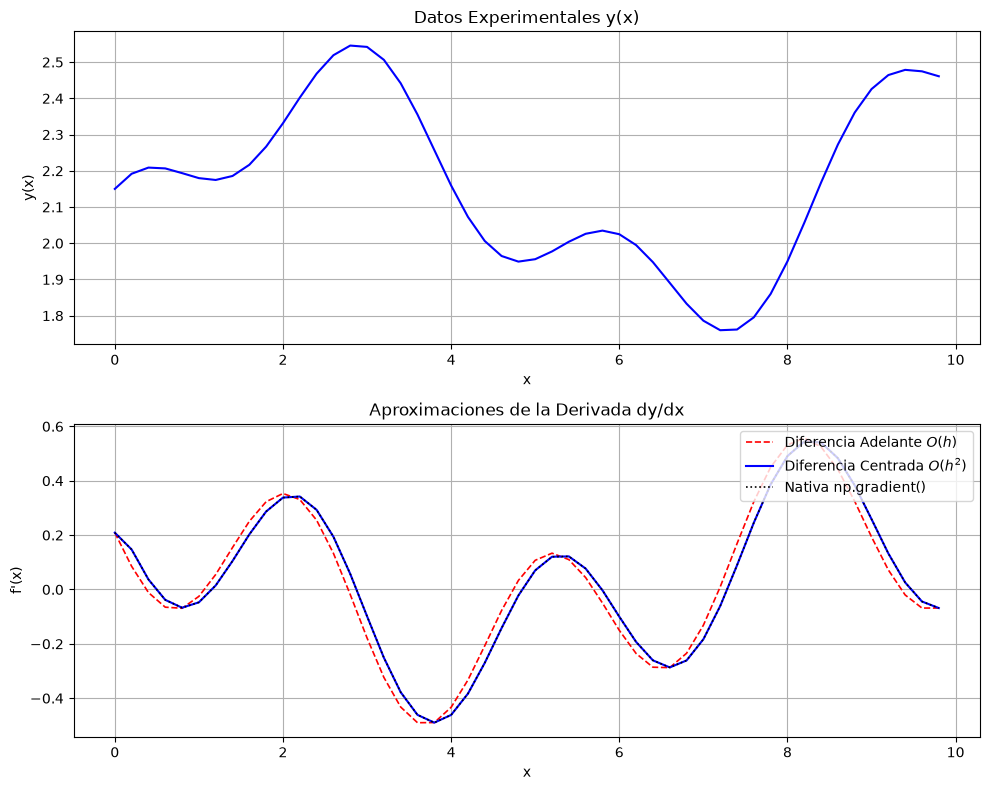

In [6]:
plt.figure(figsize=(10, 8))

# Subplot 1: Datos experimentales originales
plt.subplot(2, 1, 1)
plt.plot(x, y, "b-", linewidth=1.5, label="y(x)")
plt.title("Datos Experimentales y(x)")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.grid(True)

# Subplot 2: Comparación de derivadas
plt.subplot(2, 1, 2)
plt.plot(
    x,
    df_fwd,
    "r--",
    linewidth=1.2,
    label="Diferencia Adelante $O(h)$",
)
plt.plot(
    x,
    df_cent,
    "b-",
    linewidth=1.5,
    label="Diferencia Centrada $O(h^2)$",
)
plt.plot(
    x,
    df_numpy,
    "k:",
    linewidth=1.2,
    label="Nativa np.gradient()",
)
plt.title("Aproximaciones de la Derivada dy/dx")
plt.xlabel("x")
plt.ylabel("f'(x)")
plt.grid(True)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()